# Изучение рынка питейных заведений в Москве с целью обнаружения факторов, которые влияют на рейтинг

- Автор: Сорокин Денис
- Дата: 17.03.2026

### Цели и задачи проекта

Для помощи закзачикам с выбором подходящего места для заведения, необходимо провести исследовательский анализ данных по существующим заведениям Москвы на 2022 год.

### Описание данных

<b> Файл: `/datasets/rest_info.csv`
Информация о заведениях общественного питания.

| Столбец | Описание |
|---------|----------|
| `id` | PK - уникальный идентификатор |
| `name` | Название заведения |
| `address` | Адрес заведения |
| `district` | Административный район (например, Центральный административный округ) |
| `category` | Категория заведения (кафе, пиццерия, кофейня и др.) |
| `hours` | Дни и часы работы |
| `rating` | Рейтинг в Яндекс Картах (0.0 – 5.0) |
| `chain` | Сетевое заведение: `0` — нет, `1` — да |
| `seats` | Количество посадочных мест |

<b> Файл: `/datasets/rest_price.csv`
Информация о ценах и среднем чеке.

| Столбец | Описание |
|---------|----------|
| `id` | PK - уникальный идентификатор |
| `price` | Категория цен (ниже среднего, средние и т.д.) |
| `avg_bill` | Строковое описание среднего чека (например, «Средний счёт: 1000–1500 ₽») |
| `middle_avg_bill` | Числовая оценка среднего чека (медиана диапазона или единственное число) |
| `middle_coffee_cup` | Числовая оценка цены чашки капучино |

<b> Важные примечания
- **Логика расчета:**
  - Если указан диапазон (например, `1000–1500`), записывается медиана.
  - Если указано одно число, записывается оно.
  - Если строка не начинается с нужной подстроки («Средний счёт» или «Цена одной чашки капучино»), значение не заполняется.

### Содержимое проекта

### Шаг 1. Загрузка данных и знакомство с ними
### Шаг 2. Предобработка данных
### Шаг 3. Исследовательский анализ данных
### Шаг 4. Итоговый вывод и рекомендации
---

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from phik import phik_matrix

In [2]:
df_rest = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
df_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомьтесь с данными и изучите общую информацию о них.

In [3]:
df_rest.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [5]:
df_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
df_rest['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [7]:
df_rest.isna().sum() / len(df_rest)

id          0.000000
name        0.000000
category    0.000000
address     0.000000
district    0.000000
hours       0.063764
rating      0.000000
chain       0.000000
seats       0.429574
dtype: float64

In [8]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [9]:
df_price.isna().sum() / len(df_price)

id                   0.000000
price                0.183095
avg_bill             0.059635
middle_avg_bill      0.224002
middle_coffee_cup    0.868162
dtype: float64

---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

**Анализ df_rest:**
- В таблице всего 8406 строк и 9 столбцов. Данные включают в себя описание различных точек питания 8 видов по Москве из 9 разных районов. Пропуски имеются в столбцах с часами работы (6% от всего количества строк) и количеством посадочных мест (43% от всего количества строк). Для столбцов rating, seats и chain можно изменить тип данных, понизив размерность для экономии памяти.

**Анализ df_price:**
- В таблице всего 4058 строк и 5 столбцов. Пропуски имеются во всех столбцах, кроме уникального идентификатора.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [10]:
df = pd.merge(df_rest, df_price, on='id', how='left')

In [11]:
print('Количество строк в df_rest: ', df_rest.shape[0])
print('Количество строк в df_price: ', df_price.shape[0])
print('Количество строк в df (поулченным путём слияния df_rest и df_price): ', df.shape[0])

Количество строк в df_rest:  8406
Количество строк в df_price:  4058
Количество строк в df (поулченным путём слияния df_rest и df_price):  8406


В итоговом датафрейме получилось столько же строк, сколько и в основной таблице со списком заведений `df_rest`

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [13]:
for col in ['rating','seats', 'middle_avg_bill', 'middle_coffee_cup']:
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in ['chain']:
    df[col] = pd.to_numeric(df[col], downcast='integer')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 730.6+ KB


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [14]:
print('Всего строк: ', len(df))
df.isna().sum().sort_values(ascending=False)

Всего строк:  8406


middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
dtype: int64

In [15]:
df['hours'] = df['hours'].fillna('Неизвестно')

In [16]:
df['seats'] = df.groupby('category')['seats'].transform(
    lambda x: x.fillna(int(x.median()))
)

In [17]:
df['price'] = df['price'].fillna('Неизвестно')

В столбце `hours` пропущенные значения я заменил на значение "Неизвестно". В столбце `seats` - на медиану значений по категории. В столбце `price` - отобрал те значения, в строках которых в столбце avg_bill - тоже 'NaN', и тоже заменил на значение "Неизвестно".

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [18]:
# Сначала нормализуем данные
df['name'] = df['name'].str.strip().str.lower()
df['address'] = df['address'].str.strip()

In [19]:
df.duplicated().sum() 

0

In [20]:
df.duplicated(subset=['name', 'address']).sum() 

3

In [21]:
df.drop_duplicates(subset=['name', 'address'])

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,60.0,Неизвестно,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,80.0,Неизвестно,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,суши мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0,Неизвестно,NaN,NaN,NaN
8402,ee6bb7c3650e47bd8186fca08eda1091,миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0,Неизвестно,NaN,NaN,NaN
8403,62e8c64d4c89467aba608e39ef87616b,самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,Неизвестно,Средний счёт:от 150 ₽,150.0,NaN
8404,06a0db5ecd4842d48cd6350aa923e297,чайхана sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,Неизвестно,NaN,NaN,NaN


In [22]:
df['seats'] = pd.to_numeric(df['seats'], downcast='integer')

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [23]:
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [24]:
def is_24_7(row):
    if row == 'ежедневно, круглосуточно':
        return 1
    return 0

df['is_24_7'] = df['hours'].apply(is_24_7)

In [25]:
df['is_24_7'].value_counts(normalize=True)

0    0.913157
1    0.086843
Name: is_24_7, dtype: float64

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

* Добавлен новый столбец `is_24_7`, который строится в зависимоти от графика работы (`hours`).
* Были удалены дубликаты строк по назвнанию и адресу заведения.
* Были заменены пропуски в колонках `hours`, `seats`, `price`.


## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

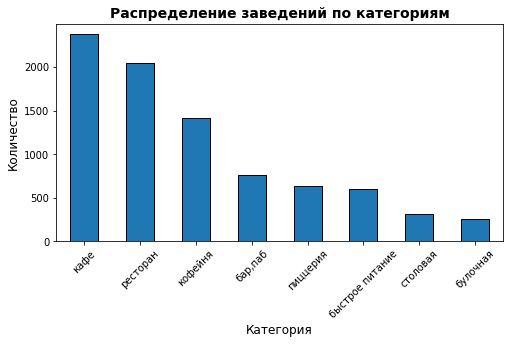

кафе               0.282893
ресторан           0.243041
кофейня            0.168094
бар,паб            0.091006
пиццерия           0.075303
быстрое питание    0.071734
столовая           0.037473
булочная           0.030454
Name: category, dtype: float64

In [26]:
bar = df['category'].value_counts().plot(
    kind='bar',
    figsize=(8, 4),
    edgecolor='black',
    rot=45)

plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.title('Распределение заведений по категориям', fontsize=14, fontweight='bold')
plt.show()

df['category'].value_counts(normalize=True)

Топ-3 категории: кафе, ресторан и кофейня

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

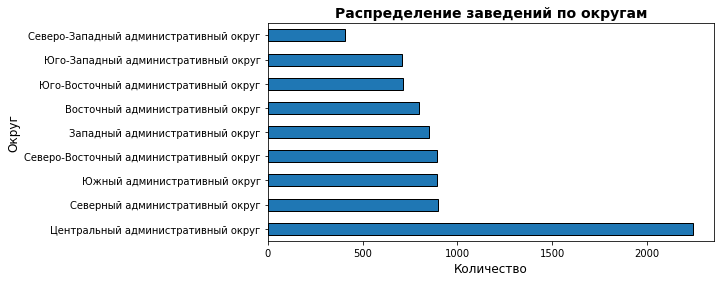

Центральный административный округ         0.266714
Северный административный округ            0.107066
Южный административный округ               0.106115
Северо-Восточный административный округ    0.105996
Западный административный округ            0.101237
Восточный административный округ           0.094932
Юго-Восточный административный округ       0.084939
Юго-Западный административный округ        0.084345
Северо-Западный административный округ     0.048656
Name: district, dtype: float64

In [27]:
bar = df['district'].value_counts().plot(
    kind='barh',
    figsize=(8, 4),
    edgecolor='black'
    )

plt.xlabel('Количество', fontsize=12)
plt.ylabel('Округ', fontsize=12)
plt.title('Распределение заведений по округам', fontsize=14, fontweight='bold')
plt.show()
df['district'].value_counts(normalize=True)

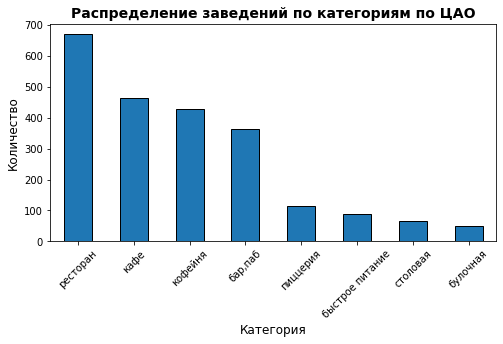

ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64

In [28]:
bar = df[df['district'] == 'Центральный административный округ']['category'].value_counts().plot(
    kind='bar',
    figsize=(8, 4),
    edgecolor='black',
    rot=45)

plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.title('Распределение заведений по категориям по ЦАО', fontsize=14, fontweight='bold')
plt.show()
df[df['district'] == 'Центральный административный округ']['category'].value_counts(normalize=True)

Из визуализации видно, что к ЦАО относится 27% заведений от всего количества, а вот СЗАО - всего 5%.

Из распределения категорий заведений внутри ЦАО явно преобладают рестораны - целых 30% от всего количества заведений внутри округа. Далее примерно равномерно распределены кафе, кофейни и бары, пабы: 20%, 19% и 16% соотвественно. Остальные категории занимают 5% и менее от общего количества.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

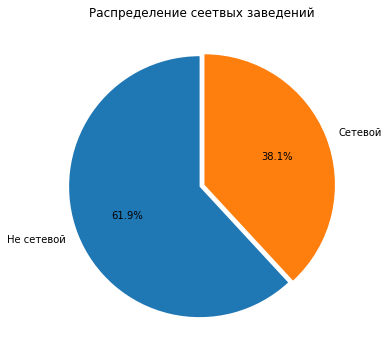

In [29]:
counts = df['chain'].value_counts()
labels = ['Не сетевой', 'Сетевой']

plt.figure(figsize=(8, 6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.02)
)
plt.title('Распределение сеетвых заведений')
plt.show()

In [30]:
df[df['chain'] == 1]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN,0
13,aea18265b0a0415893f1e796b82568fe,буханка,булочная,"Москва, Базовская улица, 15, корп. 1",Северный административный округ,"ежедневно, 08:00–22:00",4.8,1,180,Неизвестно,NaN,NaN,NaN,0
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"Москва, Ижорский проезд, 5",Северный административный округ,"ежедневно, круглосуточно",4.4,1,50,Неизвестно,NaN,NaN,NaN,1
20,1ab5691e4da844d3abadf085e0957852,чебуреки манты,кафе,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",4.3,1,148,Неизвестно,NaN,NaN,NaN,0
23,78709462f2b3480f825489a5321a3563,буханка,булочная,"Москва, Лобненская улица, 13к2",Северный административный округ,"ежедневно, 08:00–22:00",4.7,1,50,Неизвестно,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8317,715f296da82f44bcaf94e26fbeb2202b,беседка,кафе,"Москва, Кузьминская улица, 10",Юго-Восточный административный округ,"ежедневно, 11:00–23:00",4.1,1,60,Неизвестно,NaN,NaN,NaN,0
8340,cc23f746c1684b1fbe4bdeecced07a5f,семейный очаг,ресторан,"Москва, Шоссейная улица, 13",Юго-Восточный административный округ,"ежедневно, 12:00–00:00",4.3,1,98,средние,Средний счёт:до 1000 ₽,1000.0,NaN,0
8372,47b4a384611948bcb8e8dedde505ed8e,чайхана sabr,ресторан,"Москва, улица Хлобыстова, 22",Юго-Восточный административный округ,"ежедневно, 10:00–00:00",3.9,1,32,средние,Средний счёт:150–350 ₽,250.0,NaN,0
8379,aae09f55091e4c1390b61a47267c26e4,лагман хаус,кафе,"Москва, Новороссийская улица, 14, стр. 2",Юго-Восточный административный округ,"ежедневно, 10:00–00:00",4.3,1,40,Неизвестно,NaN,NaN,NaN,0


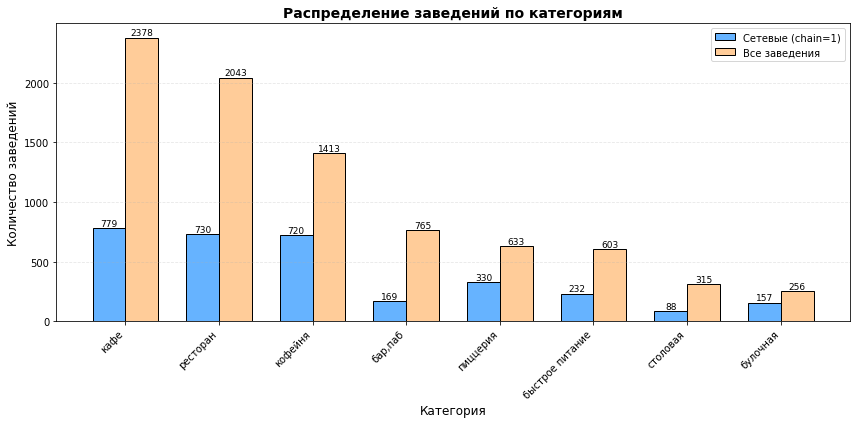

,chain_count,total_count,chain_relation
булочная,157,256,0.613281
пиццерия,330,633,0.521327
кофейня,720,1413,0.509554
быстрое питание,232,603,0.384743
ресторан,730,2043,0.357318
кафе,779,2378,0.327586
столовая,88,315,0.279365
"бар,паб",169,765,0.220915


In [31]:
chain1_counts = df[df['chain'] == 1]['category'].value_counts()
total_counts = df['category'].value_counts()

categories = total_counts.index.tolist()
x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, [chain1_counts.get(cat, 0) for cat in categories], 
               width, label='Сетевые (chain=1)', color='#66b3ff', edgecolor='black')
bars2 = ax.bar(x + width/2, [total_counts[cat] for cat in categories], 
               width, label='Все заведения', color='#ffcc99', edgecolor='black')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Категория', fontsize=12)
ax.set_ylabel('Количество заведений', fontsize=12)
ax.set_title('Распределение заведений по категориям', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

chain_df = pd.merge(chain1_counts, total_counts, left_index=True, right_index=True)
chain_df['chain_relation'] = chain_df.iloc[:, 0] / chain_df.iloc[:, 1]
chain_df.columns = ['chain_count', 'total_count', 'chain_relation']
chain_df.sort_values(by='chain_relation', ascending=False)

При изучении визуализации касающейся сетевого признака заведений, я могу сделать вывод, что более 60% заведений не являются сетевыми. После рассмотрения диаграммы с количеством заведений каждой категории с разрезом на сетевой признак, я выявил, что следующие заведения чаще являются сетевыми:
- Булочная - 61% от общего количества всех булочных
- Пиццерия - 52% от общего количества всех пиццерий
- Кофейня - 51% от общего количества всех кофейнь

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [32]:
df['seats'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    8406.000000
mean       92.533785
std        94.880737
min         0.000000
25%        55.000000
50%        75.000000
75%        86.000000
90%       180.000000
95%       250.000000
99%       490.500000
max      1288.000000
Name: seats, dtype: float64

In [33]:
df[df['seats'] > 1000]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
2713,8d07e2d1810b4dca9d4cb247d0335df3,ваня и гоги,"бар,паб","Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"ежедневно, 11:00–06:00",4.2,0,1040,высокие,Средний счёт:1000–2500 ₽,1750.0,NaN,0
2722,4731af3e68bb449fb2b34493fadfaed1,маргарита,быстрое питание,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"ежедневно, 10:00–22:00",4.3,1,1040,Неизвестно,NaN,NaN,NaN,0
2770,4c196f841b0046b3ab3a60d3ed52bfc5,шоколадница,кофейня,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"пн-ср 11:00–23:00; чт 11:00–00:00; пт,сб 11:00...",4.1,1,1040,Неизвестно,NaN,NaN,NaN,0
2966,6b611f2fc2084078952aaef40780f11c,матрешка,кафе,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,Неизвестно,4.0,0,1040,Неизвестно,NaN,NaN,NaN,0
4231,30d6c2abb42748bb98c01b1ed366e253,рестобар argomento,столовая,"Москва, Кутузовский проспект, 41, стр. 1",Западный административный округ,"ежедневно, 12:00–23:00",4.2,0,1200,высокие,Средний счёт:2500–5000 ₽,3750.0,NaN,0
6518,fbf22d98b62a47fbb2a71be3545f16b2,delonixcafe,ресторан,"Москва, проспект Вернадского, 94, корп. 1",Западный административный округ,"ежедневно, круглосуточно",4.1,0,1288,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,1
6524,c93d20f53072495c9cf2e489914cb8a5,ян примус,ресторан,"Москва, проспект Вернадского, 121, корп. 1",Западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,1,1288,выше среднего,Средний счёт:1500 ₽,1500.0,NaN,0
6574,5925d9677fe24778a27e35ccd88c0a2d,мюнгер,пиццерия,"Москва, проспект Вернадского, 97, корп. 1",Западный административный округ,"пн-пт 08:00–21:00; сб,вс 10:00–21:00",4.8,1,1288,Неизвестно,NaN,NaN,NaN,0
6641,0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"Москва, проспект Вернадского, 84, стр. 1",Западный административный округ,"ежедневно, 08:30–20:00",4.3,1,1288,Неизвестно,NaN,NaN,NaN,0
6658,19a223ff04f74af7a12bd87b77ce468b,гудбар,"бар,паб","Москва, проспект Вернадского, 97, корп. 1",Западный административный округ,"пн-пт 11:00–23:00; сб,вс 13:00–23:00",4.1,0,1288,средние,Средний счёт:700 ₽,700.0,NaN,0


In [34]:
df[df['seats'] > 500]['seats'].value_counts()

625     23
1288    11
650      6
1040     4
644      2
585      2
660      2
920      2
600      1
675      1
1200     1
760      1
Name: seats, dtype: int64

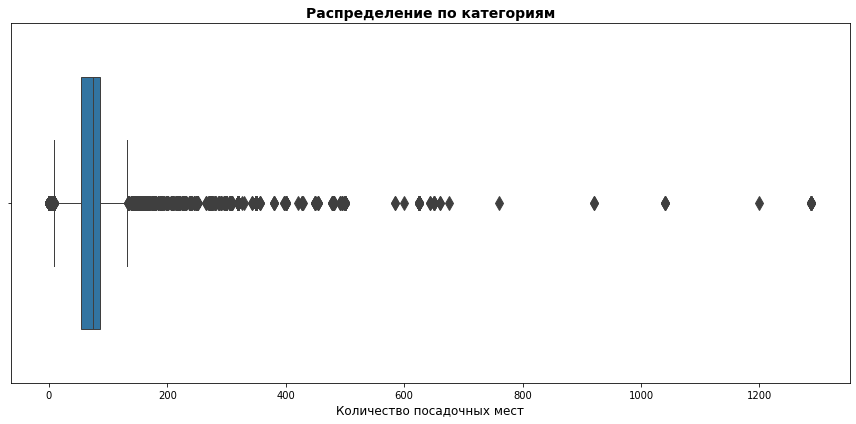

In [35]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='seats',
    width=0.7,
    linewidth=1,      # толщина контура ящика
    fliersize=10       # размер точек-выбросов
)
plt.xlabel('Количество посадочных мест', fontsize=12)
plt.title('Распределение по категориям', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

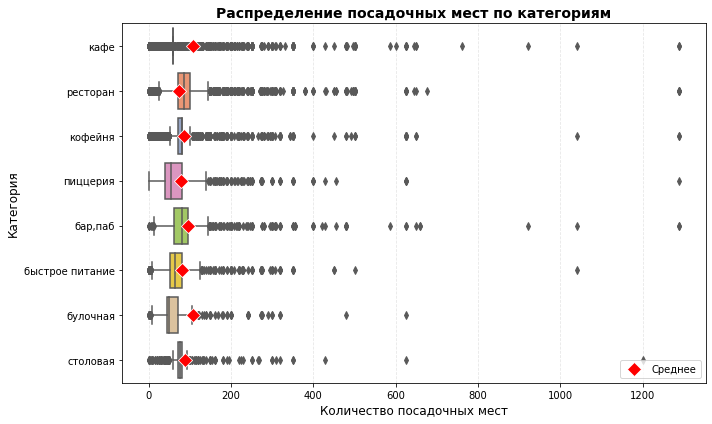

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='seats', y='category', 
            palette='Set2', linewidth=1.5)

mean_values = df.groupby('category')['seats'].mean().reset_index()
sns.scatterplot(data=mean_values, x='seats', y='category', 
                color='red', s=100, marker='D', label='Среднее', zorder=5)

plt.xlabel('Количество посадочных мест', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.title('Распределение посадочных мест по категориям', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
df['seats'] = df['seats'].mask(df['seats'] > 250, np.nan)
df['seats'] = df.groupby('category')['seats'].transform(
    lambda x: x.fillna(int(x.median()))
) 

In [38]:
df[df['category'] == 'кафе']['seats'].describe()

count    2378.000000
mean       66.837679
std        42.142492
min         0.000000
25%        60.000000
50%        60.000000
75%        60.000000
max       250.000000
Name: seats, dtype: float64

In [39]:
df['seats'].describe()

count    8406.000000
mean       76.587913
std        45.075882
min         0.000000
25%        55.000000
50%        70.000000
75%        86.000000
max       250.000000
Name: seats, dtype: float64

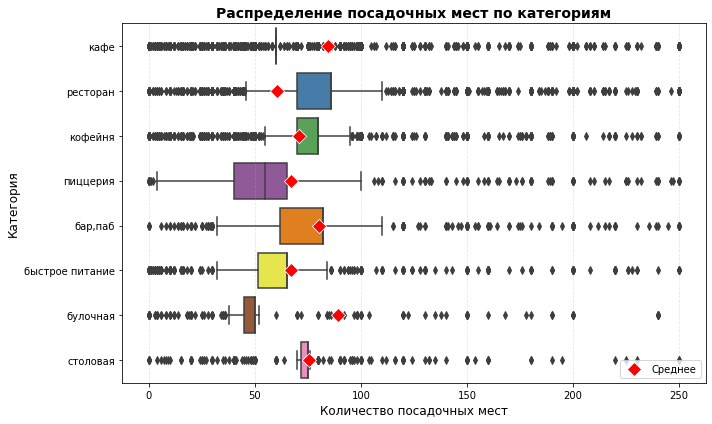

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='seats', y='category', 
            palette='Set1', linewidth=1.5)
mean_values = df.groupby('category')['seats'].mean().reset_index()
sns.scatterplot(data=mean_values, x='seats', y='category', 
                color='red', s=100, marker='D', label='Среднее', zorder=5)

plt.xlabel('Количество посадочных мест', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.title('Распределение посадочных мест по категориям', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---
В этой задаче я исследовал количество посадочных мест в заведениях. В данных встречались аномальные значения: несколько строк были с количеством посадочных мест > 500. Предполагаю, что это означало, что либо пользователь ввёл количество кв. метров заведения, либо количество посадочных мест было неизвестно, либо роль сыграл человеческий фактор при заполнении данных (лишниий 0). Выбросами я считал данные, лежавшие выше 95 процентиля. Их я заменил на медианное значение по категориям.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [41]:
df['rating'].describe()

count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

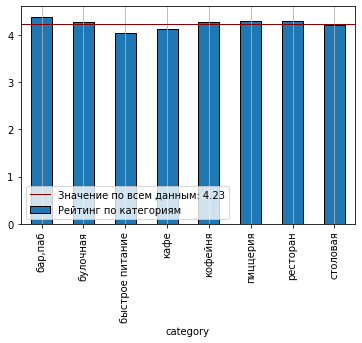

In [42]:
df.groupby('category')['rating'].mean().plot(
    kind='bar',
    edgecolor='black',
    label='Рейтинг по категориям'
)
plt.grid(axis='y', alpha=1, linestyle='--')

plt.axhline(df['rating'].mean(), color='darkred',
                linestyle='-', linewidth=1,
                label='Значение по всем данным: ' + str(round(df['rating'].mean(), 2)))

plt.grid()
plt.legend()
plt.show()


В разрезе категорий рейтинг распределен равномерно (~ 4.23)

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [43]:
corr_matrix = phik_matrix(df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']],
                          interval_cols=['seats'])

In [44]:
rating_corr = corr_matrix['rating'].sort_values(ascending=False)

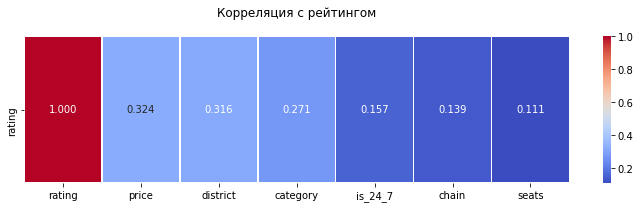

In [45]:
plt.figure(figsize=(10, 3))
sns.heatmap(rating_corr.to_frame().T, annot=True, cmap='coolwarm', 
            fmt='.3f', linewidths=.5)
plt.title('Корреляция с рейтингом', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

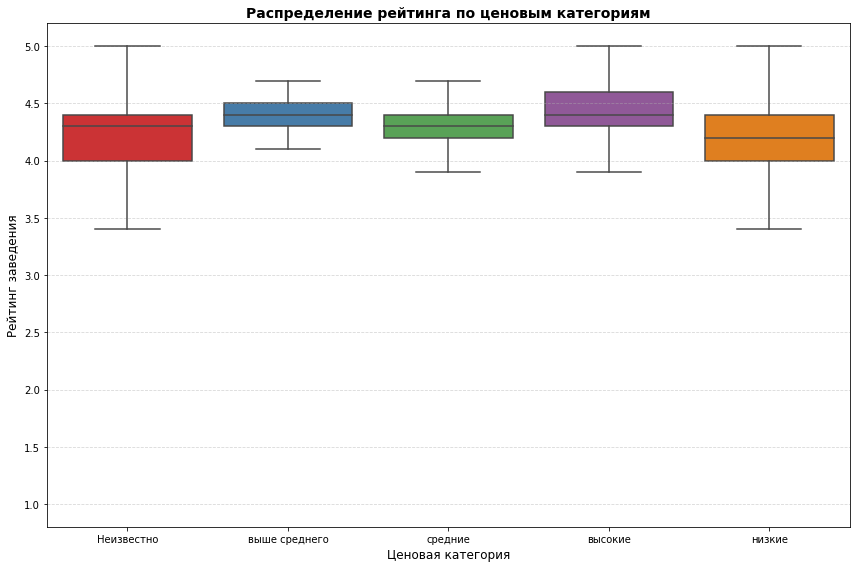

In [46]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df,
    x='price',
    y='rating',
    fliersize=0,
    palette='Set1',
    linewidth=1.5
)

plt.xlabel('Ценовая категория', fontsize=12)
plt.ylabel('Рейтинг заведения', fontsize=12)
plt.title('Распределение рейтинга по ценовым категориям', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Самым влиятельным столбцом на рейтинг оказался ценовой диапазон заведения (0.324). На втором месте по корреляции с целевой переменной идёт административный район Москвы (0.316).

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

,name,id
0,шоколадница,120
1,домино'с пицца,76
2,додо пицца,74
3,one price coffee,71
4,яндекс лавка,69
5,cofix,65
6,prime,50
7,хинкальная,44
8,кофепорт,42
9,кулинарная лавка братьев караваевых,39


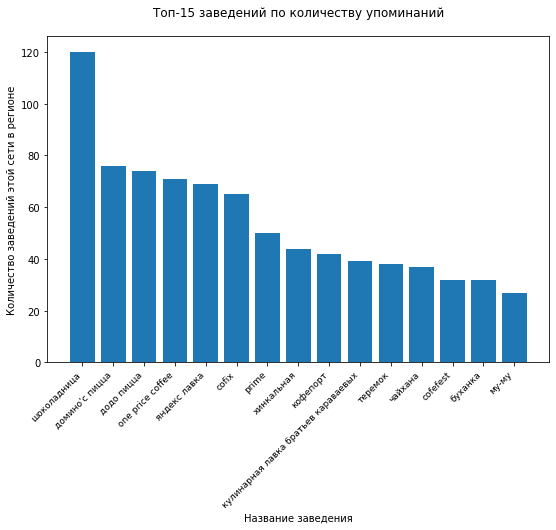

In [47]:
top15 = df.groupby(df[df['chain'] == 1]['name']).agg({'id': 'count', 'rating': 'mean'}).sort_values(by='id', ascending=False).head(15)
top15 = top15.reset_index()

plt.figure(figsize=(9, 6))
plt.bar(
    top15['name'],
    top15['id']
)
plt.title('Топ-15 заведений по количеству упоминаний', fontsize=12, pad=20)
plt.xlabel('Название заведения')
plt.ylabel('Количество заведений этой сети в регионе')
plt.xticks(rotation=45, ha='right', fontsize=9)

top15[['name', 'id']]


,name,rating
13,буханка,4.396875
9,кулинарная лавка братьев караваевых,4.394872
7,хинкальная,4.322727
2,додо пицца,4.286487
14,му-му,4.229630
0,шоколадница,4.177500
1,домино'с пицца,4.169737
8,кофепорт,4.147619
10,теремок,4.123684
6,prime,4.116000


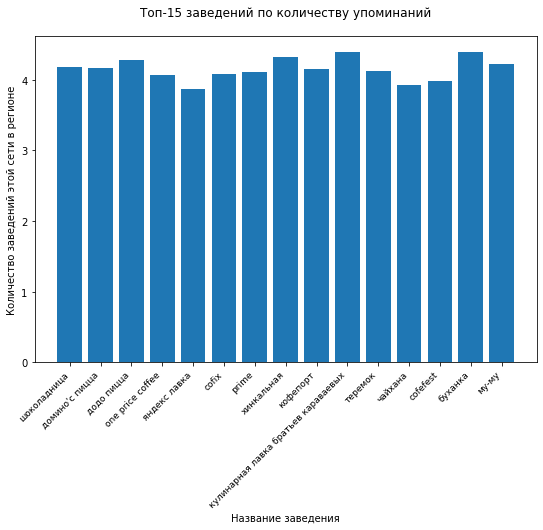

In [48]:
plt.figure(figsize=(9, 6))
plt.bar(
    top15['name'],
    top15['rating']
)
plt.title('Топ-15 заведений по количеству упоминаний', fontsize=12, pad=20)
plt.xlabel('Название заведения')
plt.ylabel('Количество заведений этой сети в регионе')  
plt.xticks(rotation=45, ha='right', fontsize=9)

top15[['name', 'rating']].sort_values(by='rating', ascending=False)

In [49]:
df[['name', 'category']][df['name'].isin(top15['name'])].drop_duplicates('name')

,name,category
13,буханка,булочная
32,додо пицца,пиццерия
34,домино'с пицца,пиццерия
46,cofefest,кофейня
52,cofix,кофейня
80,му-му,кафе
107,теремок,ресторан
109,чайхана,кафе
138,хинкальная,быстрое питание
143,one price coffee,кофейня


Стоит отметить, что больше всего по количеству заведений в Москве - сеть Шоколадница. Так же важно отметить, что среди топ-15 сетевых точек нет ни одного бара,паба. Сетью с самым низким рейтингом (3.87) стала Янекс.Лавка

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


,district,middle_avg_bill
0,Западный административный округ,1000.0
1,Центральный административный округ,1000.0
2,Северо-Западный административный округ,700.0
3,Северный административный округ,650.0
4,Юго-Западный административный округ,600.0
5,Восточный административный округ,575.0
6,Северо-Восточный административный округ,500.0
7,Южный административный округ,500.0
8,Юго-Восточный административный округ,450.0


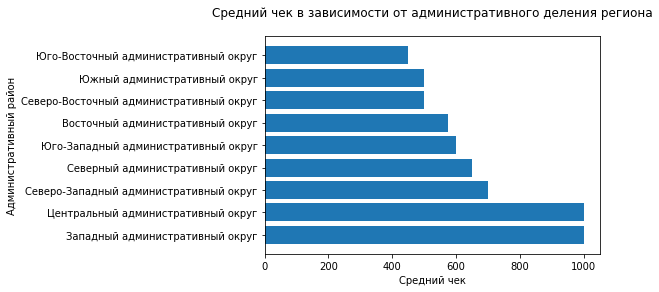

In [50]:
top_avg_bill = df.groupby(df['district'])['middle_avg_bill'].median().sort_values(ascending=False).reset_index()
plt.barh(top_avg_bill['district'],
         top_avg_bill['middle_avg_bill']
        )
plt.title('Средний чек в зависимости от административного деления региона', fontsize=12, pad=20)
plt.xlabel('Средний чек')
plt.ylabel('Административный район')
top_avg_bill

Опираясь на полученную визуализацию, можно сделать вывод, что самые дорогие средние чеки находятся в центре (1000), на западе (1000) и северо-западе (700). 

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

После предобработки и исследовательского анализа данных можно сделать следующие промежуточные выводы:
### Обработка данных
- Исходные данные объединены из двух таблиц (rest_info.csv и rest_price.csv) в единый датафрейм из 8406 записей.
- Проведена оптимизация типов данных: числовые колонки (rating, seats, middle_avg_bill, middle_coffee_cup) преобразованы в float32, колонка chain — в int8, что позволило сократить потребление памяти.
- Пропущенные значения обработаны стратегически:
  - hours — заменено на «Неизвестно» (6% пропусков);
  - seats — заполнено медианой по категории заведения (43% пропусков);
  - price — заменено на «Неизвестно».
- Удалено 3 неявных дубликата по комбинации «название + адрес».
- Создан новый признак is_24_7 для идентификации круглосуточных заведений.

### Ключевые наблюдения
**Категории заведений:** наиболее распространены «кафе», «ресторан» и «кофейня» — они формируют основу рынка общественного питания Москвы.

**Географическое распределение:** заведения неравномерно распределены по административным округам; Центральный округ имеет самую высокую концентрацию точек.

**Сетевые заведения:** в топ-15 по количеству упоминаний выигрывает безимянный формат кафе, а так же сетевые форматы (Шоколадница, Додо Пицца, Теремок и др.); при этом отсутствуют бары и пабы, что может указывать на нишевый характер этого сегмента.

**Ценовая дифференциация:** наблюдается чёткая градация среднего чека по удалённости от центра:
- Центральный округ: ~1191 ₽
- Западный округ: ~1053 ₽
- Северный округ: ~928 ₽
- ...
- Юго-Восточный округ: ~654 ₽ (минимум)

## 4. Итоговый вывод и рекомендации


## 4.1. Общий обзор проделанной работы
В ходе проекта был проведён полный цикл анализа данных о заведениях общественного питания Москвы: от загрузки и предобработки до исследовательской визуализации. Данные очищены от дубликатов, обработаны пропуски, созданы новые признаки. С помощью визуализаций изучены распределения по категориям, районам, рейтингам и ценам.
## 4.2. Главные выводы
- Рынок структурирован: доминируют кафе и рестораны, сетевые игроки занимают значительную долю в топовых позициях. Среди сетвых заведений доминирует "Шоколадница": разница по количеству заведений с топ-2 почти 100%.
- Цены коррелируют с локацией: чем ближе к центру и западу, тем выше средний чек (вплоть до 1000); разница между самым дорогим и самым дешёвым округом превышает 80%.
- В центре находится более 26% заведений от общего количества по Москве.
- Корреляционная матрица показывает, что чем выше ценовая категория заведения, тем выше его рейтинг.
- Круглосуточный формат — редкость: лишь 8% заведений работает 24/7, что может быть точкой роста для новых проектов.
## 4.3. Рекомендации для заказчика
+ Для выбора локации:
При запуске заведения премиум-сегмента рассмотрите Центральный или Западный округа — там выше платёжеспособность аудитории.
Для формата «быстрое питание» или демократичного кафе перспективны Юго-Восточный и Северо-Восточный округа: ниже конкуренция среди дорогих заведений, но есть спрос.
+ Для позиционирования:
Избегайте прямого копирования сетевых концепций из топ-15 (особенно - "Шоколадница") — рынок насыщен.
Рассмотрите ниши с низкой представленностью: бары/пабы, специализированные кофейни, этнические кухни, булочные.
+ Для ценообразования:
Используйте данные о среднем чеке по округу как ориентир, но учитывайте формат заведения и целевую аудиторию.
В периферийных районах делайте акцент на соотношение «цена/качество», в центре — на уникальность опыта и сервис.